Task 14


Executive Summary

Task 1 (0.6808) and Task 4 (0.6157) are the strongest retrievals — the revenue summary and cash flow pages are semantically close to the query wording. VLM retrieved the correct information

Task 2 (0.5130) and Task 3 (0.5111) are moderate — the regional breakdown and pipeline pages use more technical/clinical language that diverges slightly from the plain-English query, reducing similarity. Vlm retrieved incorrect information
​

Important Caveat
A high score guarantees the most relevant page was found relative to all other pages, but does not guarantee the page contains the exact answer. For example, a score of 0.68 on Page 1 simply means the cover/summary page was semantically closest — not that it is the only page with revenue data. This is why the VLM's visual reading step is essential: it validates and extracts the actual figures from the retrieved page

Required Task 14

Build a Page-Wise Visual RAG (Retrieval-Augmented Generation) system to analyse AstraZeneca's FY and Q4 2025 earnings report. Rather than simply reading the PDF as text, your system will identify the most relevant page for a given query, render it as an image, and use a Vision-Language Model (VLM) to extract and interpret the information visually — just as a financial analyst would.

This mirrors a real-world analyst workflow: locate the right section of a report, then read it carefully to extract structured insights.

Setup
Use the notebook structure from the lab session. Your system should use:

Embeddings: sentence-transformers/all-MiniLM-L6-v2 (local, CPU)

VLM: Qwen/Qwen2.5-VL-3B-Instruct (local, T4 GPU)

PDF: AstraZeneca-Q4-2025-earnings.pdf

Runtime: Google Colab with T4 GPU

Tasks
Task 1 — Revenue Table Extraction
Use your Visual RAG system to answer the following query:

"What were AstraZeneca's total Product Sales and Alliance Revenue for FY 2025, and how did each change compared to FY 2024?"

Task 2 — Regional Revenue Breakdown
Issue the following query:

"Which geographic region had the highest Total Revenue growth in FY 2025, and what was the growth rate at constant exchange rates?"

Task 3 — R&D Pipeline Interpretation
Issue the following query:

"Which medicines received regulatory approvals in the US between November 2025 and February 2026, and for what indications?"

Task 4 — Audit Mode Query
Design your own audit-style prompt — one that demands precise numerical figures with an explicit instruction to cite the page or table the number came from. Run it through your system and report:

Your chosen query The page retrieved The VLM's response A verification of at least two specific figures against the source document

Your prompt should target a different section of the report from Tasks 1–3. Good candidates include the cash flow statement (Table 12), the Reported-to-Core reconciliation (Table 10), or the currency sensitivity table (Table 16).



Install dependencies

In [3]:
# Install required packages
!pip install -q pymupdf sentence-transformers transformers accelerate qwen-vl-utils pillow numpy torch torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 17.9 MB/s eta 0:00:00


Imports and configuration

In [1]:
import fitz  # PyMuPDF
import torch
import numpy as np
from PIL import Image
from sentence_transformers import SentenceTransformer
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
import io, os, textwrap

PDF_PATH = "6.AstraZeneca-Q4-2025-earnings.pdf"  # Upload this to Colab
EMBED_MODEL_ID = "sentence-transformers/all-MiniLM-L6-v2"
VLM_MODEL_ID   = "Qwen/Qwen2.5-VL-3B-Instruct"
RENDER_DPI     = 150  # Higher = sharper image for VLM

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")


Device: cuda


PDF -Per-page text Extraction

In [2]:
def extract_pages(pdf_path: str) -> list[dict]:
    """Return a list of {page_num, text} dicts for every page."""
    doc = fitz.open(pdf_path)
    pages = []
    for i, page in enumerate(doc):
        text = page.get_text("text").strip()
        pages.append({"page_num": i + 1, "text": text})
    doc.close()
    print(f"Extracted {len(pages)} pages from PDF.")
    return pages

pages = extract_pages(PDF_PATH)


Extracted 39 pages from PDF.


Build Semantic Index with Sentence -Transformers

In [3]:
# Load embedding model (CPU)
embed_model = SentenceTransformer(EMBED_MODEL_ID, device="cpu")

# Encode all page texts
page_texts   = [p["text"] for p in pages]
page_embeds  = embed_model.encode(page_texts, show_progress_bar=True,
                                   batch_size=32, normalize_embeddings=True)
page_embeds  = np.array(page_embeds)  # shape: (N, 384)

print(f"Index built: {page_embeds.shape}")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Index built: (39, 384)


Retrieval Function

In [4]:
def retrieve_top_k(query: str, k: int = 1) -> list[dict]:
    """
    Embed the query and return the top-k most relevant pages
    using cosine similarity (embeddings are L2-normalised → dot product = cosine).
    """
    q_emb = embed_model.encode([query], normalize_embeddings=True)
    scores = page_embeds @ q_emb.T  # (N, 1)
    scores = scores.flatten()
    top_k_idx = np.argsort(scores)[::-1][:k]
    results = []
    for idx in top_k_idx:
        results.append({
            "page_num": pages[idx]["page_num"],
            "score":    float(scores[idx]),
            "text":     pages[idx]["text"][:400]   # preview only
        })
    return results

# Quick smoke test
test = retrieve_top_k("total product sales FY 2025", k=3)
for r in test:
    print(f"  Page {r['page_num']}  score={r['score']:.4f}  preview: {r['text'][:80]!r}")


  Page 1  score=0.6015  preview: 'Summary \nRevenue Drivers \nR&D Progress \nSustainability \nFinancial Performance \nF'
  Page 6  score=0.5705  preview: 'Summary \nRevenue Drivers \nR&D Progress \nSustainability \nFinancial Performance \nF'
  Page 36  score=0.5460  preview: 'Summary \nRevenue Drivers \nR&D Progress \nSustainability \nFinancial Performance \nF'


Render PDF Page as PIL Image

MuPDF error: format error: No common ancestor in structure tree

Page 1 rendered: (1241, 1754)


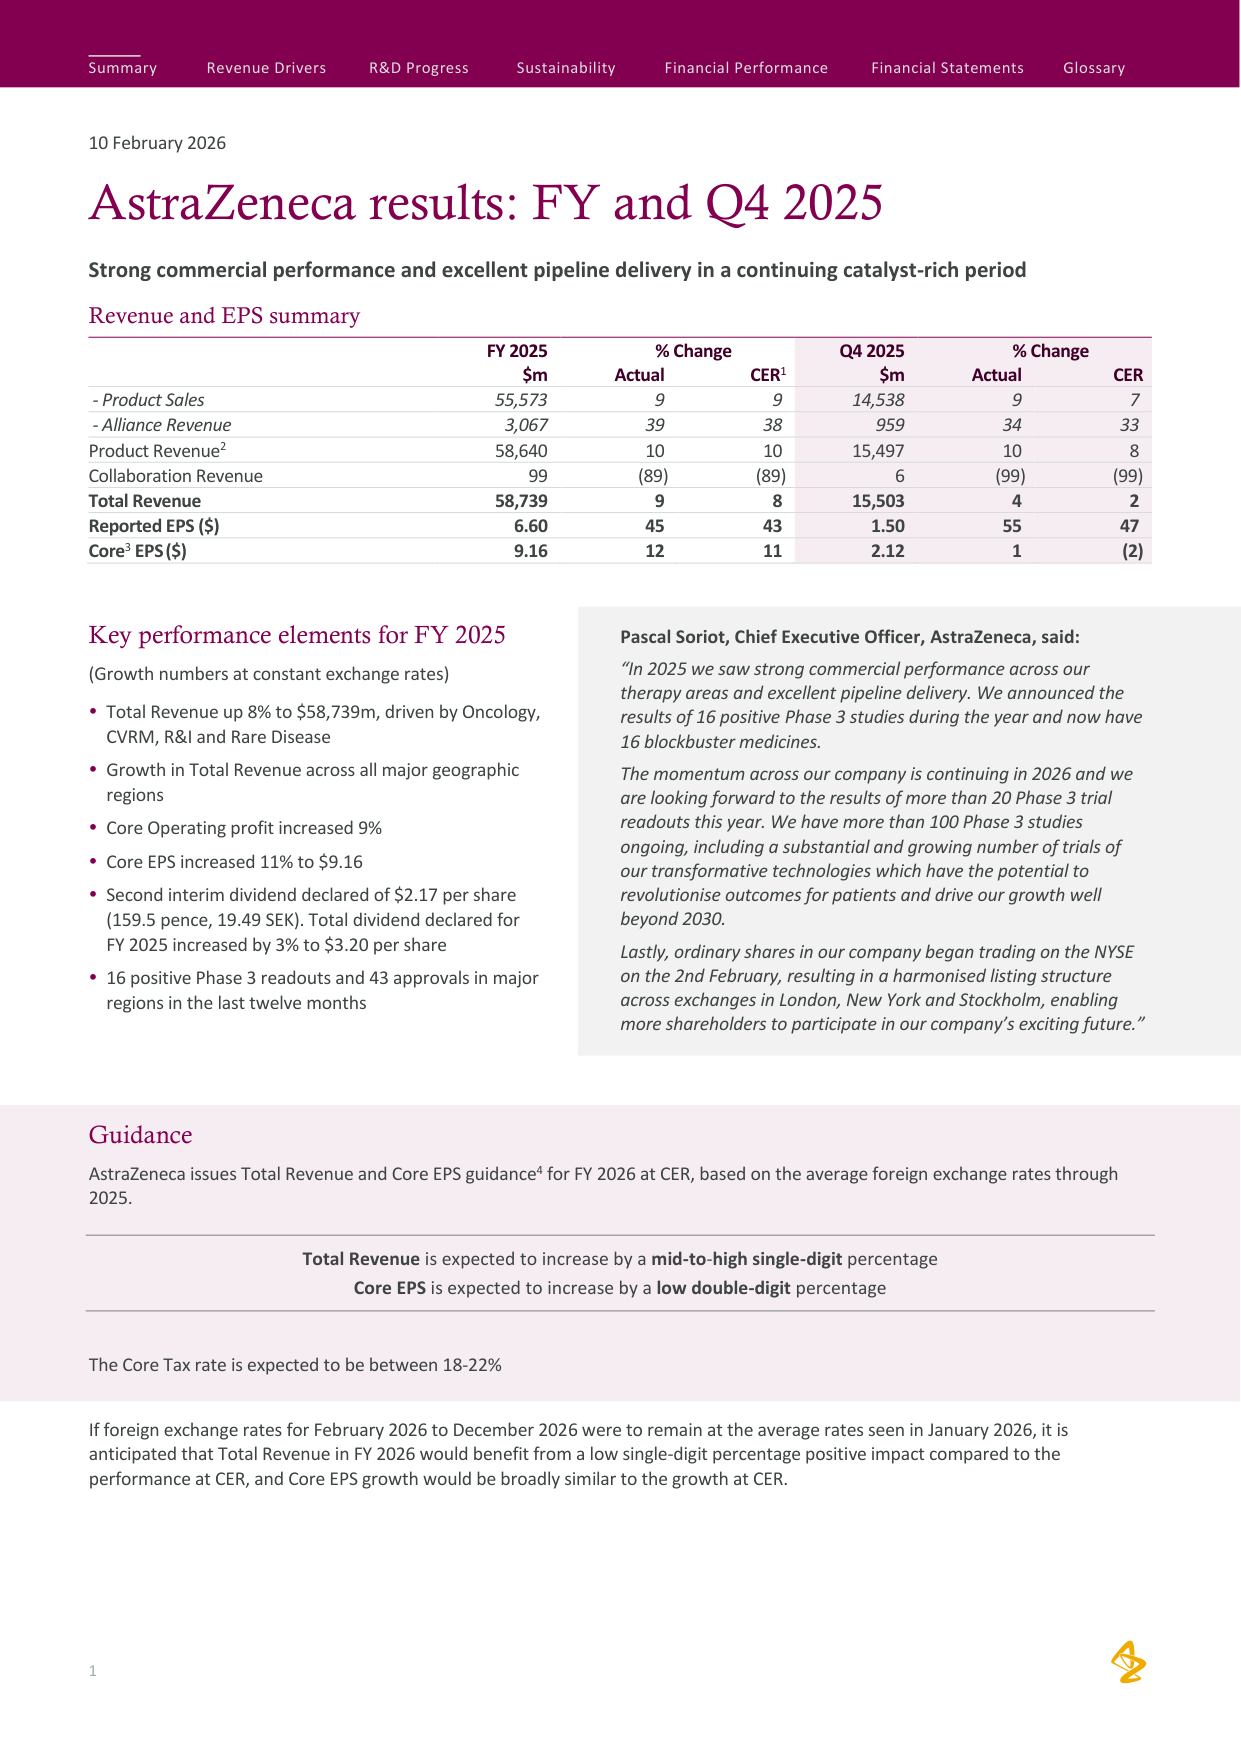

In [5]:
def render_page_image(pdf_path: str, page_num: int, dpi: int = RENDER_DPI) -> Image.Image:
    """Render a single PDF page (1-indexed) to a PIL RGB Image."""
    doc  = fitz.open(pdf_path)
    page = doc[page_num - 1]
    zoom = dpi / 72.0
    mat  = fitz.Matrix(zoom, zoom)
    pix  = page.get_pixmap(matrix=mat, alpha=False)
    img  = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
    doc.close()
    return img

# Preview page 1
img_preview = render_page_image(PDF_PATH, 1)
img_preview.save("page_preview.png")
print(f"Page 1 rendered: {img_preview.size}")
img_preview


Load Qwen2.5-VL-3B-Instruct (T4 GPU)

In [6]:
import torch
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor

VLM_MODEL_ID   = "Qwen/Qwen2.5-VL-3B-Instruct"

vlm_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    VLM_MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
    ignore_mismatched_sizes=True
)
vlm_processor = AutoProcessor.from_pretrained(VLM_MODEL_ID)
print("VLM loaded ✓")

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

VLM loaded ✓


VLM Inference Function

In [7]:
def ask_vlm(image: Image.Image, query: str, max_new_tokens: int = 512) -> str:
    """
    Pass an image and text query to Qwen2.5-VL and return the model's answer.
    Uses the chat template expected by Qwen2.5-VL.
    """
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text",  "text": query}
            ]
        }
    ]
    # Build prompt
    text_prompt = vlm_processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = vlm_processor(
        text=[text_prompt],
        images=[image],
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        output_ids = vlm_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )
    # Decode only the newly generated tokens
    generated_ids = [
        out[len(inp):]
        for inp, out in zip(inputs.input_ids, output_ids)
    ]
    response = vlm_processor.batch_decode(
        generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True
    )[0]
    return response.strip()


Master Visual RAG Pipeline

In [8]:
def visual_rag(query: str, top_k: int = 1, verbose: bool = True) -> dict:
    """
    Full Visual RAG pipeline:
      1. Retrieve most relevant page(s)
      2. Render top page as image
      3. Query VLM with the image + user question
    Returns a dict with page_num, score, image, and vlm_response.
    """
    # Step 1 – Retrieve
    hits = retrieve_top_k(query, k=top_k)
    best = hits[0]

    if verbose:
        print(f"\n{'='*60}")
        print(f"Query : {query}")
        print(f"Top   : Page {best['page_num']}  (score={best['score']:.4f})")
        print(f"{'='*60}")

    # Step 2 – Render
    img = render_page_image(PDF_PATH, best["page_num"])

    # Step 3 – VLM
    answer = ask_vlm(img, query)

    if verbose:
        print(f"\n--- VLM Response ---\n")
        print(textwrap.fill(answer, width=90))

    return {
        "query":        query,
        "page_num":     best["page_num"],
        "score":        best["score"],
        "image":        img,
        "vlm_response": answer
    }


Task 1: Revenue Table Extraction


Query : What were AstraZeneca's total Product Sales and Alliance Revenue for FY 2025, and how did each change compared to FY 2024?
Top   : Page 1  (score=0.6808)
MuPDF error: format error: No common ancestor in structure tree



The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



--- VLM Response ---

AstraZeneca's total Product Sales for FY 2025 was $55,733m, up by 9% from FY 2024. The
Alliance Revenue for FY 2025 was $3,067m, up by 39% from FY 2024.


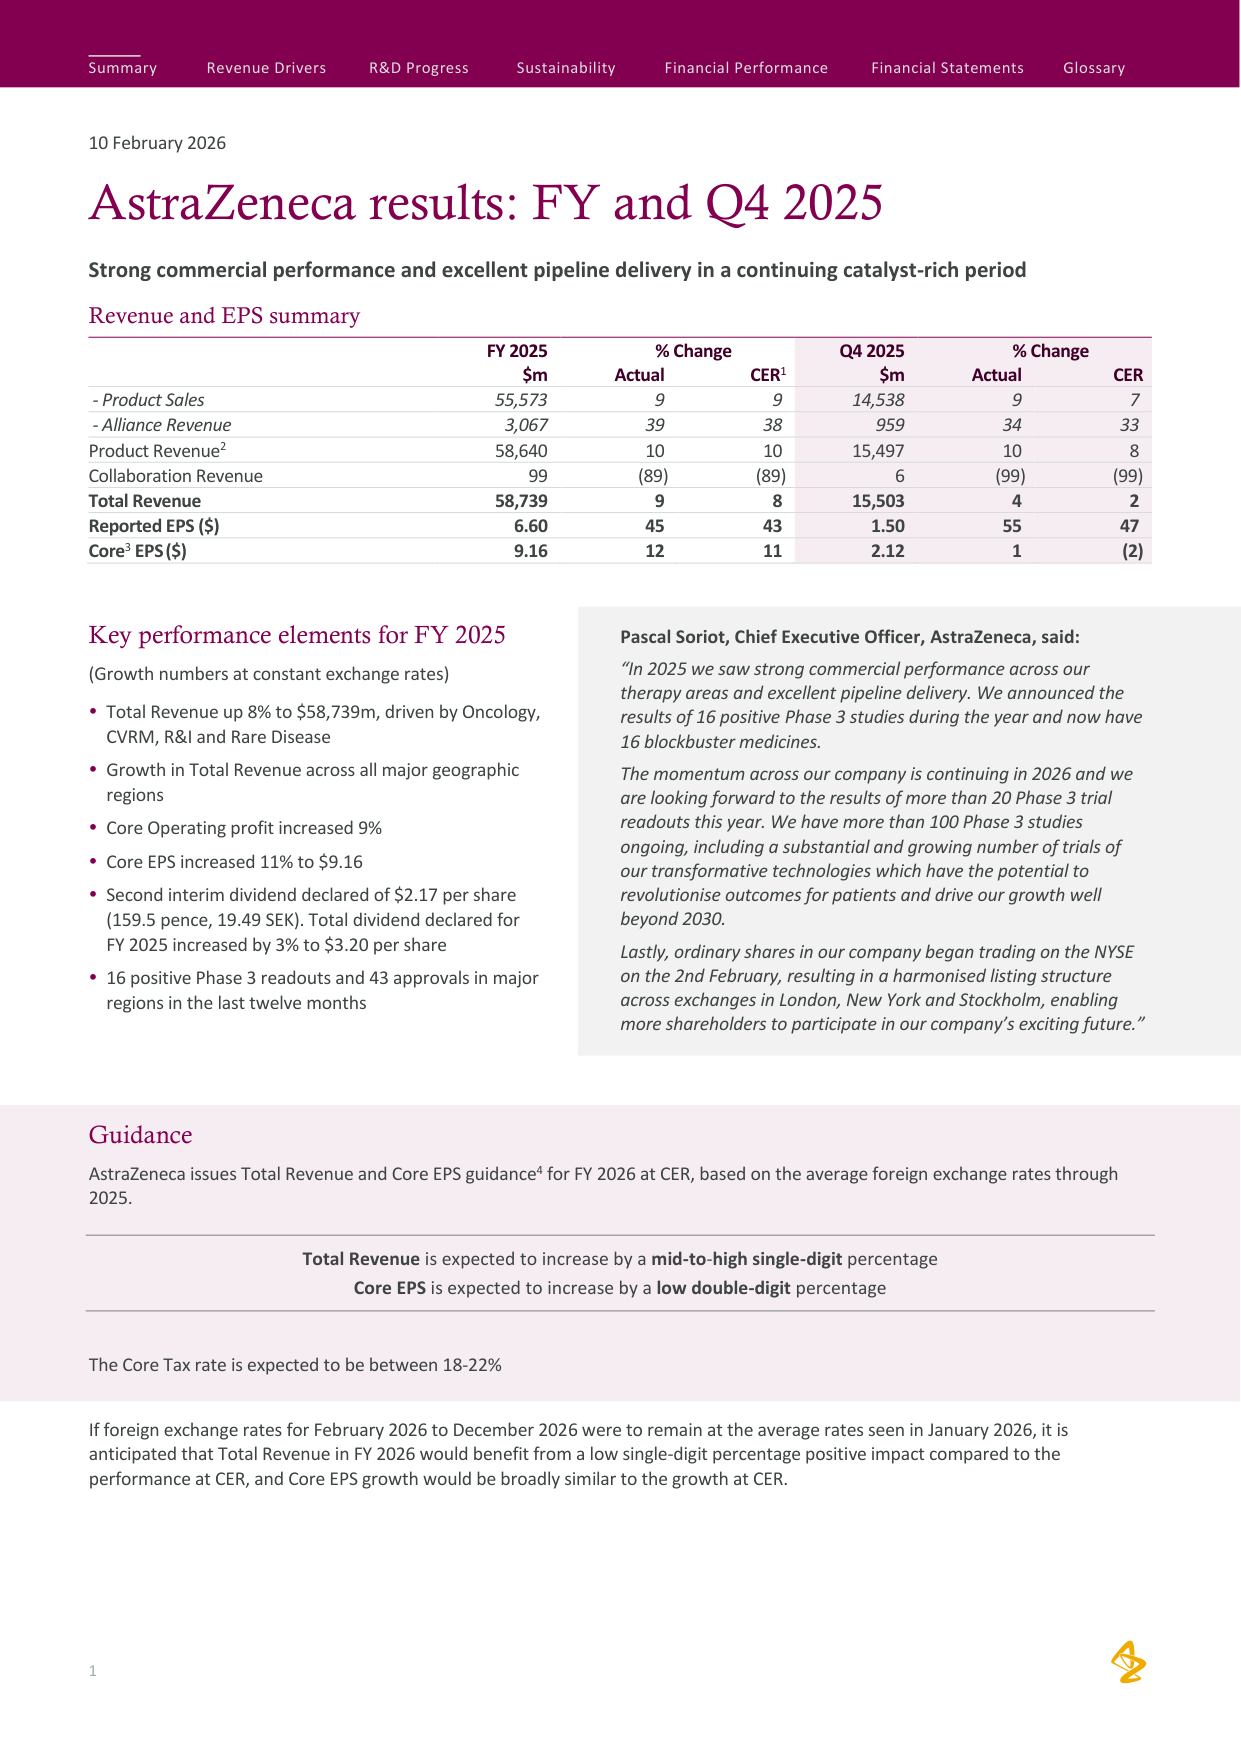

In [9]:
result_t1 = visual_rag(
    query=(
        "What were AstraZeneca's total Product Sales and Alliance Revenue "
        "for FY 2025, and how did each change compared to FY 2024?"
    )
)

# Save the retrieved page image for reference
result_t1["image"].save("task1_page.png")
result_t1["image"]


Task 2: Regional Revenue Breakdown


Query : Which geographic region had the highest Total Revenue growth in FY 2025, and what was the growth rate at constant exchange rates?
Top   : Page 1  (score=0.5130)
MuPDF error: format error: No common ancestor in structure tree


--- VLM Response ---

The Oncology, CVRM, R&I and Rare Disease regions had the highest Total Revenue growth in
FY 2025, with a growth rate of 8%.


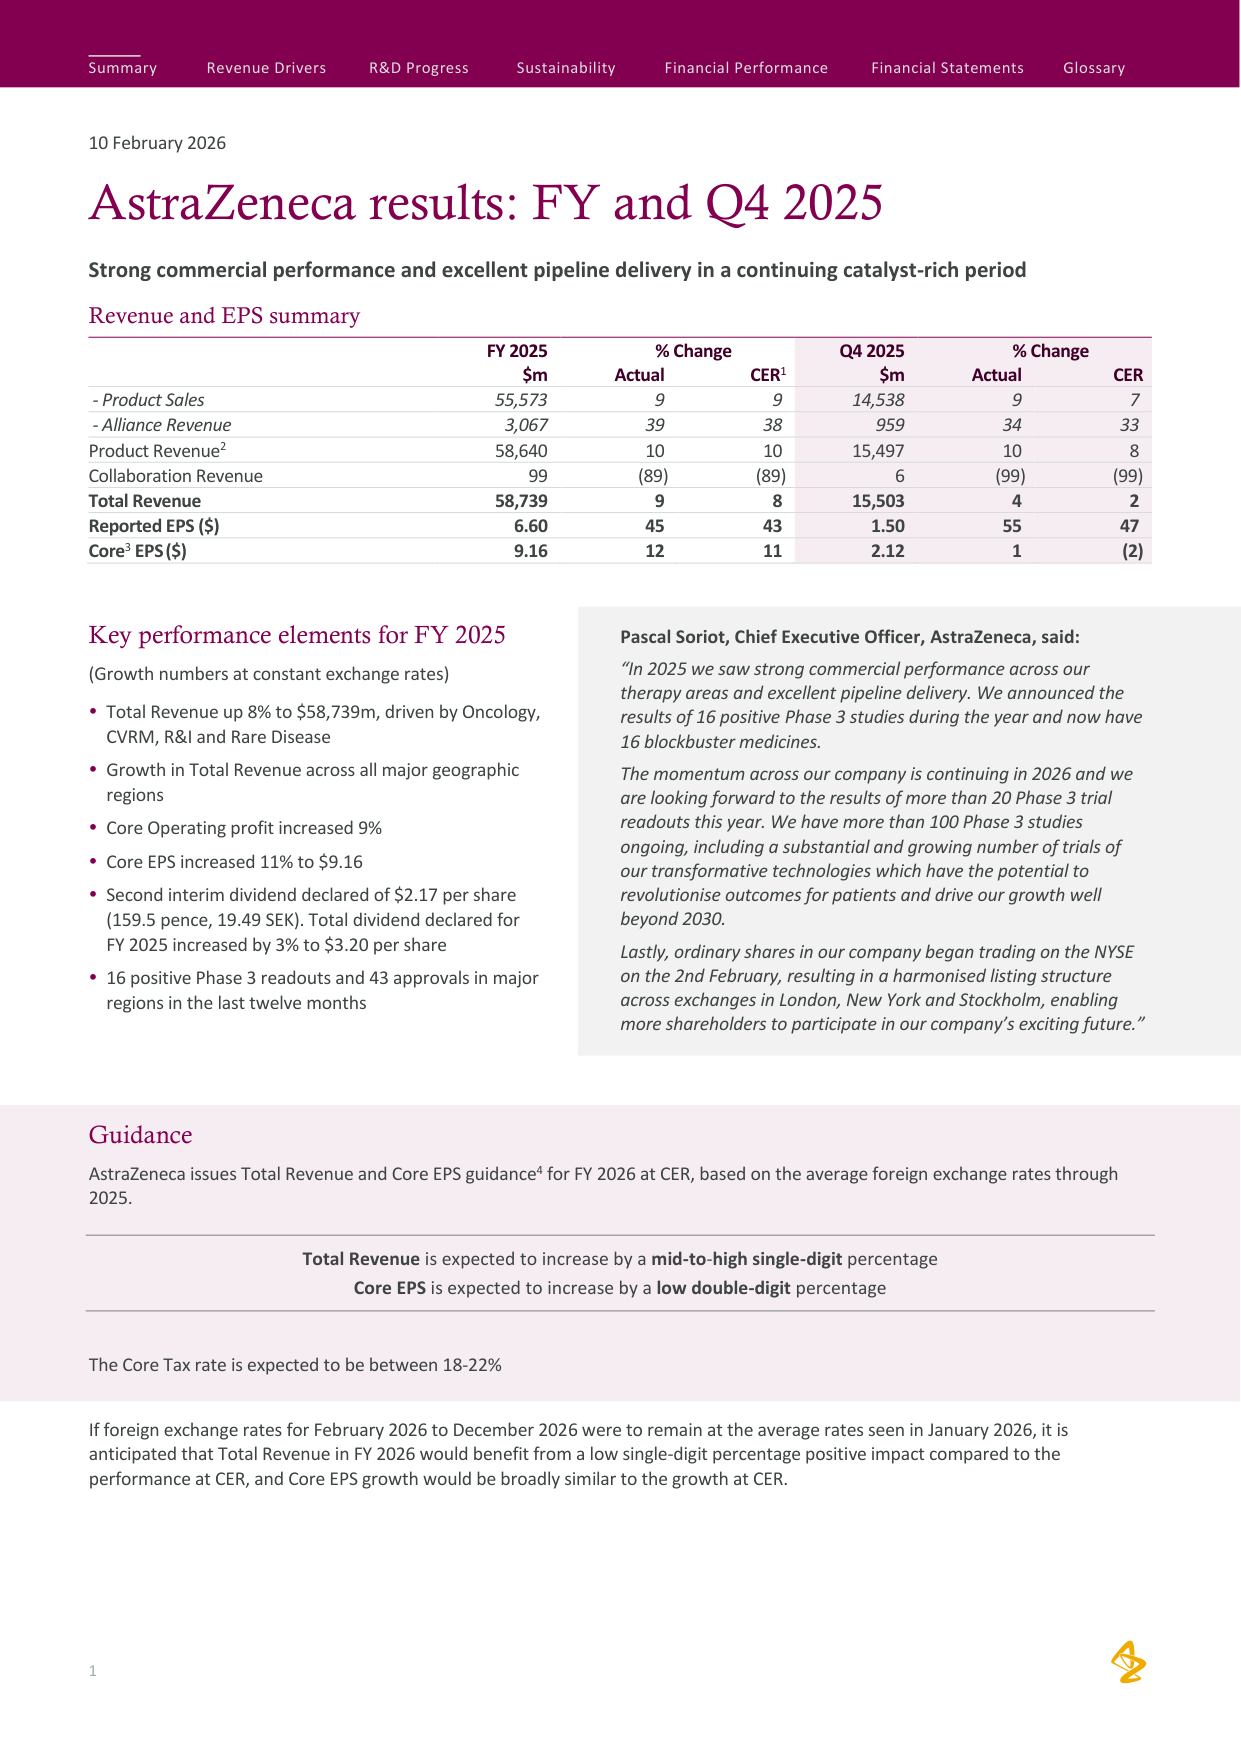

In [10]:
result_t2 = visual_rag(
    query=(
        "Which geographic region had the highest Total Revenue growth "
        "in FY 2025, and what was the growth rate at constant exchange rates?"
    )
)

result_t2["image"].save("task2_page.png")
result_t2["image"]


Task 3: R&D Pipeline — Regulatory Approvals


Query : Which medicines received regulatory approvals in the US between November 2025 and February 2026, and for what indications?
Top   : Page 13  (score=0.5111)
MuPDF error: format error: No common ancestor in structure tree


--- VLM Response ---

DESTINY-Breast09 for unresectable or metastatic HER2-positive breast cancer; DESTINY-
Breast06 for unresectable or metastatic HR-positive, HER2 low (IHC 1+ or IHC 2+/ISH-) or
HER2 ultralow (IHC 0 with membrane staining) breast cancer that has progressed on one or
more endocrine therapies in the metastatic setting; DESTINY-Gastric04 for locally advanced
or metastatic HER2-positive gastric or gastroesophageal junction adenocarcinoma who have
received one prior trastuzumab-based regimen.


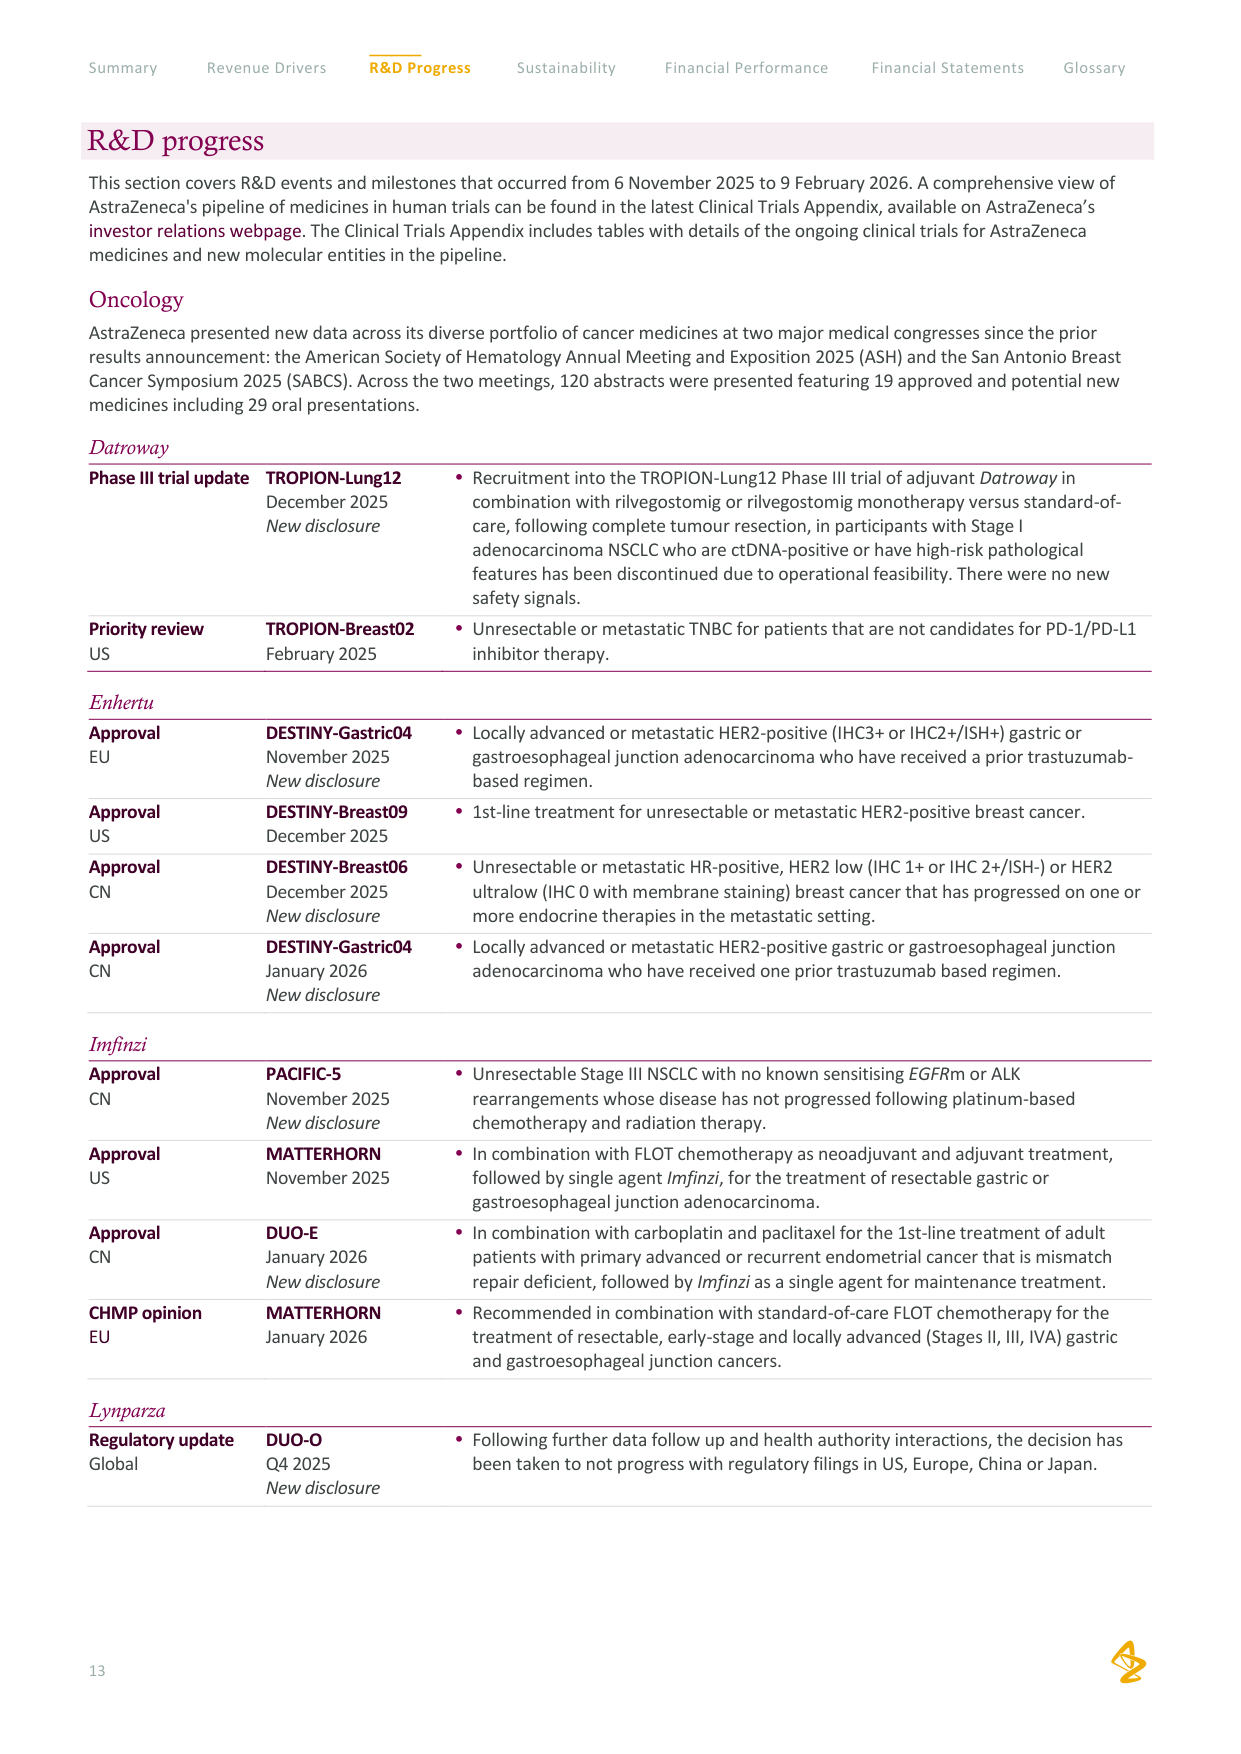

In [11]:
result_t3 = visual_rag(
    query=(
        "Which medicines received regulatory approvals in the US between "
        "November 2025 and February 2026, and for what indications?"
    )
)

result_t3["image"].save("task3_page.png")
result_t3["image"]


Task 4: Audit Mode — Cash Flow Statement


Query : From the Cash Flow Statement (Table 12), state the exact figures for 'Net cash from operating activities', 'Capital expenditure', and 'Free Cash Flow' for FY 2025 and FY 2024. You MUST cite the specific table number and page number where each figure appears. Do not estimate — only report numbers visible in the table.
Top   : Page 20  (score=0.6157)
MuPDF error: format error: No common ancestor in structure tree


--- VLM Response ---

Here are the exact figures for 'Net cash from operating activities', 'Capital
expenditure', and 'Free Cash Flow' for FY 2025 and FY 2024, as per Table 12:  - **Net cash
from operating activities**:   - FY 2025: $14,575 million   - FY 2024: $11,861 million  -
**Capital expenditure**:   - FY 2025: $3,270 million   - FY 2024: $2,218 million  - **Free
Cash Flow**:   - FY 2025: $7,767 million   - FY 2024: $3,881 million  These figures are
directly provided in Table 12 on page 20 of the document.


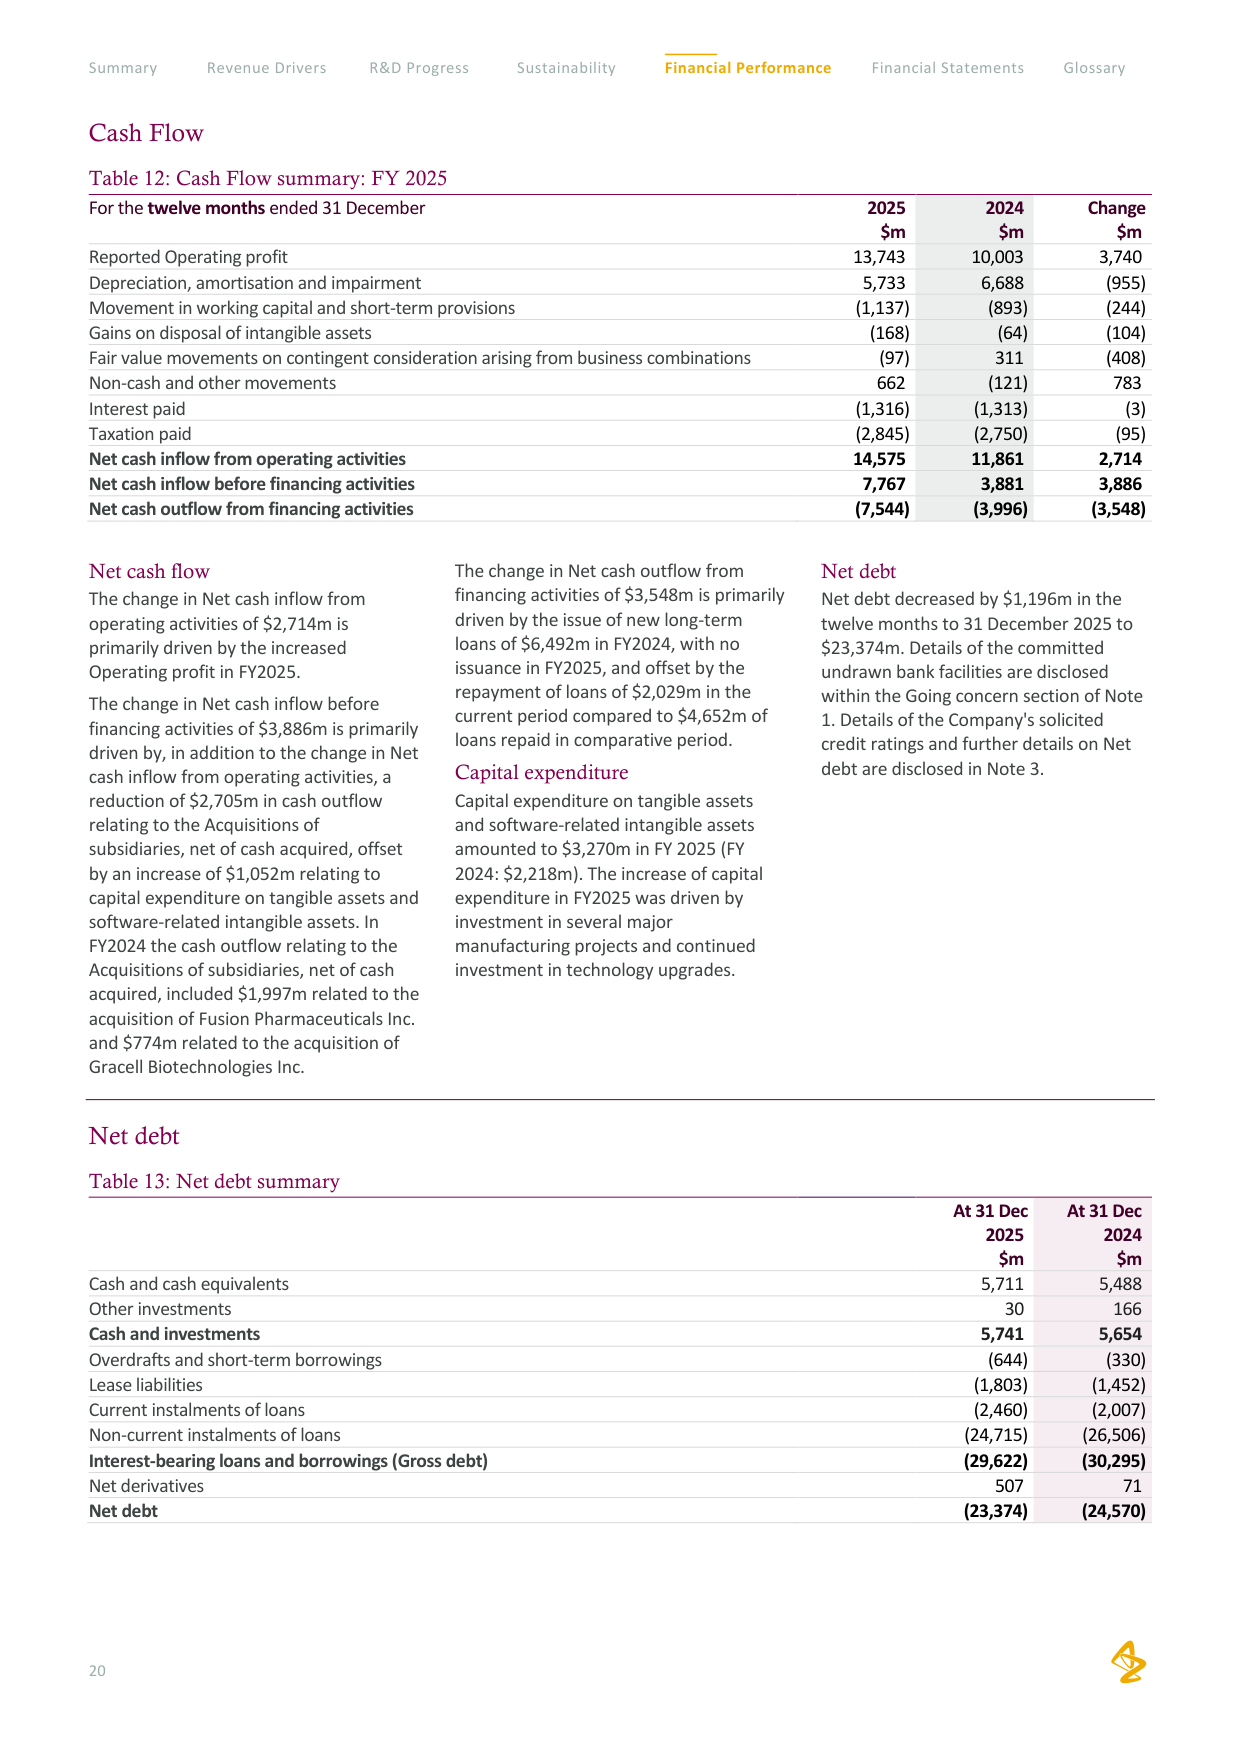

In [12]:
AUDIT_QUERY = (
    "From the Cash Flow Statement (Table 12), state the exact figures for "
    "'Net cash from operating activities', 'Capital expenditure', and "
    "'Free Cash Flow' for FY 2025 and FY 2024. "
    "You MUST cite the specific table number and page number where each "
    "figure appears. Do not estimate — only report numbers visible in the table."
)

result_t4 = visual_rag(query=AUDIT_QUERY)

result_t4["image"].save("task4_page.png")
result_t4["image"]


Task 4 Verification Panel

In [13]:
print("\n" + "="*65)
print("TASK 4 — AUDIT VERIFICATION PANEL")
print("="*65)
print(f"Chosen Query :\n  {result_t4['query']}\n")
print(f"Page Retrieved : {result_t4['page_num']}  (similarity={result_t4['score']:.4f})\n")
print("VLM Response:")
print("-"*65)
print(textwrap.fill(result_t4["vlm_response"], width=80))
print("-"*65)

# Cross-check: pull raw text from the retrieved page for manual verification
raw = pages[result_t4["page_num"] - 1]["text"]
print("\nRaw page text (first 1500 chars) for manual cross-verification:")
print(raw[:1500])



TASK 4 — AUDIT VERIFICATION PANEL
Chosen Query :
  From the Cash Flow Statement (Table 12), state the exact figures for 'Net cash from operating activities', 'Capital expenditure', and 'Free Cash Flow' for FY 2025 and FY 2024. You MUST cite the specific table number and page number where each figure appears. Do not estimate — only report numbers visible in the table.

Page Retrieved : 20  (similarity=0.6157)

VLM Response:
-----------------------------------------------------------------
Here are the exact figures for 'Net cash from operating activities', 'Capital
expenditure', and 'Free Cash Flow' for FY 2025 and FY 2024, as per Table 12:  -
**Net cash from operating activities**:   - FY 2025: $14,575 million   - FY
2024: $11,861 million  - **Capital expenditure**:   - FY 2025: $3,270 million
- FY 2024: $2,218 million  - **Free Cash Flow**:   - FY 2025: $7,767 million   -
FY 2024: $3,881 million  These figures are directly provided in Table 12 on page
20 of the document.
------------

Summary Dashboard

In [14]:
tasks = [
    ("Task 1 — Revenue Table",         result_t1),
    ("Task 2 — Regional Breakdown",    result_t2),
    ("Task 3 — R&D Approvals",         result_t3),
    ("Task 4 — Audit Cash Flow",       result_t4),
]

print(f"\n{'='*70}")
print(f"{'VISUAL RAG — SUMMARY':^70}")
print(f"{'='*70}")
print(f"{'Task':<30} {'Page':>5}  {'Score':>7}  {'Answer (first 120 chars)'}")
print(f"{'-'*70}")
for name, r in tasks:
    snippet = r["vlm_response"][:120].replace("\n", " ")
    print(f"{name:<30} {r['page_num']:>5}  {r['score']:>7.4f}  {snippet}")
print(f"{'='*70}")



                         VISUAL RAG — SUMMARY                         
Task                            Page    Score  Answer (first 120 chars)
----------------------------------------------------------------------
Task 1 — Revenue Table             1   0.6808  AstraZeneca's total Product Sales for FY 2025 was $55,733m, up by 9% from FY 2024. The Alliance Revenue for FY 2025 was 
Task 2 — Regional Breakdown        1   0.5130  The Oncology, CVRM, R&I and Rare Disease regions had the highest Total Revenue growth in FY 2025, with a growth rate of 
Task 3 — R&D Approvals            13   0.5111  DESTINY-Breast09 for unresectable or metastatic HER2-positive breast cancer; DESTINY-Breast06 for unresectable or metast
Task 4 — Audit Cash Flow          20   0.6157  Here are the exact figures for 'Net cash from operating activities', 'Capital expenditure', and 'Free Cash Flow' for FY 
